In [1]:
from qiskit import QuantumCircuit, Aer, execute
from qiskit.visualization import plot_histogram
# import matplotlib.pyplot as plt #(needed only outside of nb)

In [2]:
qc = QuantumCircuit(1,1)    # (qbits, bits)

In [4]:
qc.h(0)
qc.measure(0,0)

In [5]:
#simulating circuit
backend = Aer.get_backend('qasm_simulator') # simulator
job = execute(qc, backend)
result = job.result()

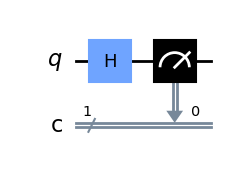

In [6]:
qc.draw('mpl')

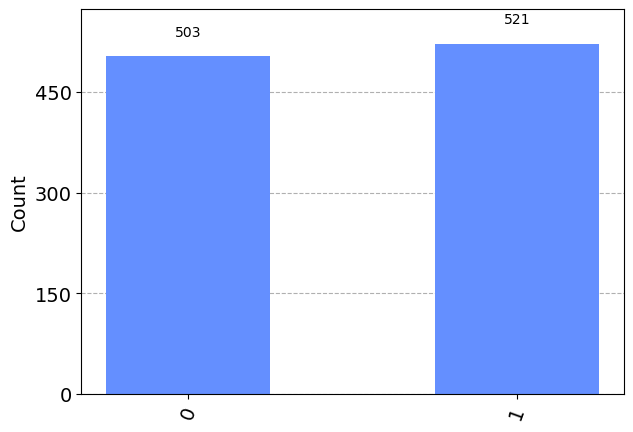

In [14]:
# entanglement
qc2 = QuantumCircuit(2,2)
qc2.h(0)
qc2.cx(0,1)
qc2.draw('mpl')
qc2.measure([0,1],[0,1])

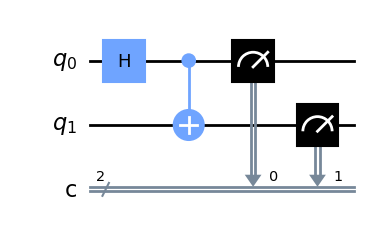

In [15]:
qc2.draw('mpl')

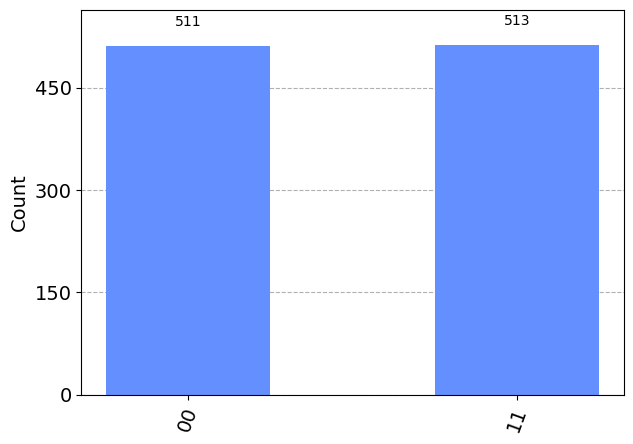

In [22]:
#simulating circuit

job2 = execute(qc2, backend)
result2 = job2.result()

c2 = result2.get_counts(qc2)
plot_histogram(c2)

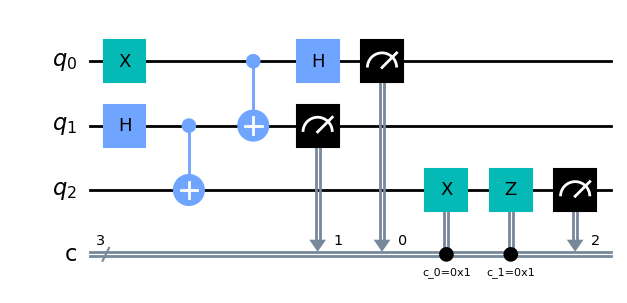

In [34]:
qc3 = QuantumCircuit(3,3)
qc3.x(0)
qc3.h(1)
qc3.cx(1, 2)
qc3.cx(0, 1)
qc3.h(0)
qc3.measure([0, 1], [0, 1])
qc3.x(2).c_if(0, 1) # X if qc(0) == 1
qc3.z(2).c_if(1, 1)
qc3.measure(2, 2)
qc3.draw('mpl')

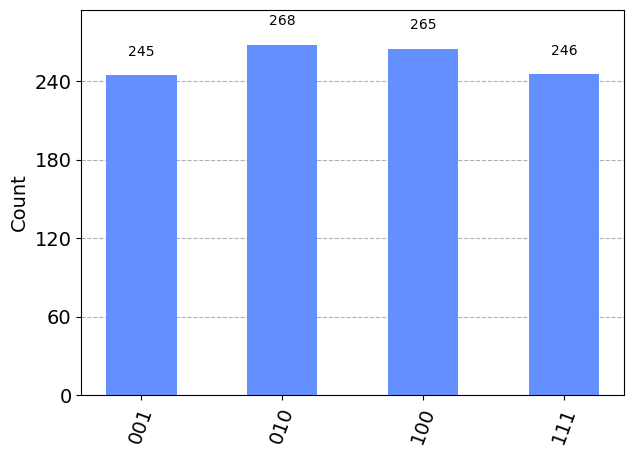

In [35]:
#simulating circuit

job3 = execute(qc3, backend)
result3 = job3.result()

c3 = result3.get_counts(qc3)
plot_histogram(c3)

In [36]:
print(result3)

Result(backend_name='qasm_simulator', backend_version='0.12.0', qobj_id='', job_id='e49a8854-37e5-406c-b2e4-52d152ab6fd4', success=True, results=[ExperimentResult(shots=1024, success=True, meas_level=2, data=ExperimentResultData(counts={'0x7': 246, '0x1': 245, '0x4': 265, '0x2': 268}), header=QobjExperimentHeader(creg_sizes=[['c', 3]], global_phase=0.0, memory_slots=3, n_qubits=3, name='circuit-116', qreg_sizes=[['q', 3]]), status=DONE, seed_simulator=1537443823, metadata={'noise': 'ideal', 'batched_shots_optimization': False, 'measure_sampling': False, 'parallel_shots': 4, 'remapped_qubits': False, 'active_input_qubits': [0, 1, 2], 'num_clbits': 3, 'parallel_state_update': 1, 'num_qubits': 3, 'device': 'CPU', 'input_qubit_map': [[2, 2], [1, 1], [0, 0]], 'method': 'stabilizer', 'fusion': {'enabled': False}}, time_taken=0.004106949)], date=2023-06-22T14:48:11.401155, status=COMPLETED, header=None, metadata={'time_taken_execute': 0.004132999, 'mpi_rank': 0, 'num_mpi_processes': 1, 'max_g